<a href="https://colab.research.google.com/github/HadzhymuradovaAnzhela/comprehensive-ecommerce-data-project/blob/main/comprehensive_ecommerce_performance_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Import

In [ ]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
from google.cloud import bigquery

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, ScalarFormatter
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, f_oneway, mannwhitneyu, kruskal, kendalltau
import statsmodels.api as sm

auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

query = """
SELECT
  ss.date,
  ss.ga_session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.medium,
  sp.channel,
  acs.account_id,
  ac.is_verified,
  ac.is_unsubscribed,
  pr.category,
  pr.name,
  pr.price,
  pr.short_description
FROM `data-analytics-mate.DA.order` o
FULL OUTER JOIN `data-analytics-mate.DA.session` ss
  ON o.ga_session_id = ss.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` pr
  ON o.item_id = pr.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` acs
  ON ss.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` ac
  ON acs.account_id = ac.id
LEFT JOIN `data-analytics-mate.DA.session_params` sp
  ON ss.ga_session_id = sp.ga_session_id
"""
query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe()
df.head()

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


# Dataset Description

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   medium             349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df.describe(include='all')

,date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
count,349545,349545.0,349545,349545,349545,349545,349545,349545,235279,349545,349545,27945.0,27945.0,27945.0,33538,33538,33538.000000,33538
unique,NaN,<NA>,6,108,3,6,10,6,9,6,5,<NA>,<NA>,<NA>,14,550,NaN,1476
top,NaN,<NA>,Americas,United States,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,BESTÅ,NaN,Chair
freq,NaN,<NA>,193179,153470,204429,238460,97254,203909,159893,119024,124425,<NA>,<NA>,<NA>,7630,1257,NaN,659
mean,2020-12-16 12:42:00.602497536,4992250296.631739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,659005.065557,0.71698,0.16944,NaN,NaN,953.298679,NaN
min,2020-11-01 00:00:00,1205.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,636133.0,0.0,0.0,NaN,NaN,3.000000,NaN
25%,2020-11-26 00:00:00,2493646855.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,647576.0,0.0,0.0,NaN,NaN,170.000000,NaN
50%,2020-12-15 00:00:00,4988476074.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,658952.0,1.0,0.0,NaN,NaN,445.000000,NaN
75%,2021-01-08 00:00:00,7491286508.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,670414.0,1.0,0.0,NaN,NaN,1195.000000,NaN
max,2021-01-31 00:00:00,9999997129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,681962.0,1.0,1.0,NaN,NaN,9585.000000,NaN


In [ ]:
df.isna().sum() / df.shape[0]*100

,0
date,0.000000
ga_session_id,0.000000
continent,0.000000
country,0.000000
device,0.000000
browser,0.000000
mobile_model_name,0.000000
operating_system,0.000000
language,32.689925
medium,0.000000


The dataset consists of 18 columns. There are 14 categorical columns: ga_session_id, continent, country, device, browser, mobile_model_name, operating_system, language, medium, channel, account_id, category, name, and short_description. The price column is the only numerical type, while the date column is the only datetime type. The columns is_verified and is_unsubscribed are boolean, represented as 1 for True and 0 for False.  
The analysis includes 349 545 unique sessions and 27 946 accounts for the period from 2020-12-16 to 2021-01-31. Most orders originated from the United States via desktop devices and the Chrome browser. Organic channels were the main source of traffic, and "Bookcases & shelving units" was the most popular category.  
Approximately 32.7% of the data in the language column is missing. These gaps occur when users block technical data in their browser settings or use privacy tools like VPNs. Significant missing data in the account and product columns reflects the natural conversion funnel. Information about accounts is missing in 92% of the rows because only 27 945 rows contain account data, as many sessions were conducted by guests. Similarly, product-related fields are populated in only 33 538 rows, which means this data is missing in 90.4% of the rows. This matches the exact number of sessions that ended with an order.

# Exploratory Data Analysis

## Key Insights

In [ ]:
total_sales = df['price'].sum()
total_order = df['price'].count()
total_account = df['account_id'].count()
print(f'Total Sales: {total_sales}. \nOrder Count: {total_order}. \nAccount Count: {total_account}.')

Total Sales: 31971731.1. 
Order Count: 33538. 
Account Count: 27945.


In [ ]:
top_3_continent = df.groupby('continent')['price'].sum().sort_values(ascending = False).head(3)
top_3_continent

,price
continent,
Americas,17665280.0
Asia,7601298.3
Europe,5934624.2


In [ ]:
top_3_continent_cnt = df['continent'].value_counts().head(3)
top_3_continent_cnt

,count
continent,
Americas,193179
Asia,83113
Europe,65135


In [ ]:
top_5_country = df.groupby('country')['price'].sum().sort_values(ascending = False).head(5)
top_5_country

,price
country,
United States,13943553.9
India,2809762.0
Canada,2437921.0
United Kingdom,938317.9
France,710692.8


In [ ]:
top_5_country_cnt = df['country'].value_counts().head(5)
top_5_country_cnt

,count
country,
United States,153470
India,32763
Canada,25994
United Kingdom,11003
France,6958


In [ ]:
top_10_category_cnt = df['category'].value_counts().head(10)
top_10_category_cnt

,count
category,
Bookcases & shelving units,7630
Chairs,5952
Sofas & armchairs,4301
Tables & desks,2941
Beds,2926
Cabinets & cupboards,2318
Outdoor furniture,2229
Children's furniture,1702
Chests of drawers & drawer units,1452


In [ ]:
top_10_category = df.groupby('category')['price'].sum().sort_values(ascending = False).head(10)
top_10_category

,price
category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


In [ ]:
top_10_category_us = df[df['country']=='United States'].groupby('category')['price'].sum().sort_values(ascending = False).head(10)
top_10_category_us

,price
category,
Sofas & armchairs,3707144.5
Chairs,2619773.8
Beds,2213058.0
Bookcases & shelving units,1567606.9
Cabinets & cupboards,994545.5
Outdoor furniture,929245.2
Tables & desks,777865.0
Chests of drawers & drawer units,382388.0
Bar furniture,330805.0


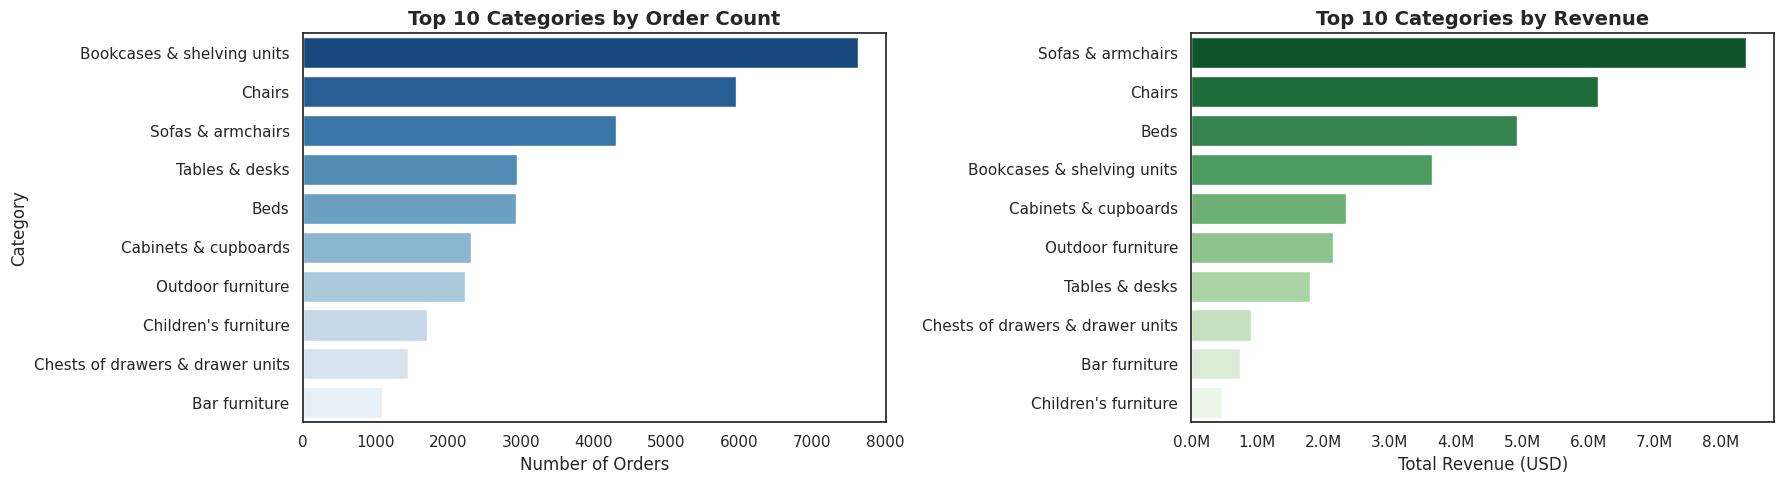

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(x=top_10_category_cnt.values,
            y=top_10_category_cnt.index,
            ax=ax[0],
            hue=top_10_category_cnt.index,
            palette="Blues_r")
ax[0].set_title("Top 10 Categories by Order Count", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Number of Orders")
ax[0].set_ylabel("Category")
sns.barplot(x=top_10_category.values,
            y=top_10_category.index,
            ax=ax[1],
            hue=top_10_category.index,
            palette="Greens_r")
ax[1].set_title("Top 10 Categories by Revenue", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Total Revenue (USD)")
ax[1].set_ylabel("")

def millions(x, pos):
    return f'{x*1e-6:.1f}M'
ax[1].xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

**Top Regions**: The most active regions in terms of both sales volume and revenue are the Americas, Asia, and Europe.  
**Leading Countries**: The United States, India, Canada, the United Kingdom, and France lead in both total revenue and number of orders.  
**Product Categories**: The Top 10 categories by revenue do not fully match the Top 10 by order count due to significant price differences per unit.  
**Most Profitable**: Sofas & Armchairs, Chairs, and Beds.    
**Most Popular** (by quantity): Bookcases & Shelving Units, Chairs, and Sofas & Armchairs.  
**USA vs Global Trends**: In the most profitable country (USA), the Top 10 categories fully align with global sales trends, showing consistent demand across these markets.

## Revenue Analysis by Segments

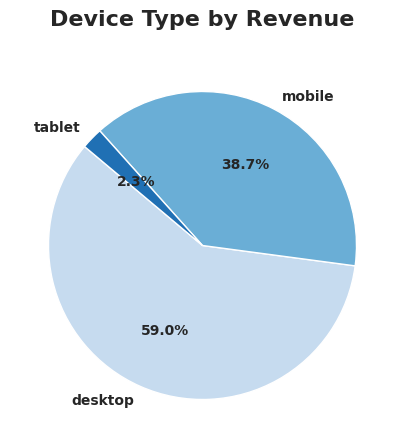

In [ ]:
revenue_by_device = df.groupby('device')['price'].sum().reset_index()
revenue_by_device['percentage'] = (revenue_by_device['price'] /revenue_by_device['price'].sum()) *100
revenue_by_device.sort_values(by='percentage', ascending = False)
plt.figure(figsize=(8, 5))
plt.pie(
    revenue_by_device['price'],
    labels=revenue_by_device['device'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(revenue_by_device)),
    startangle=140,
    textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title("Device Type by Revenue", fontsize=16, fontweight='bold', pad=20)
plt.show()

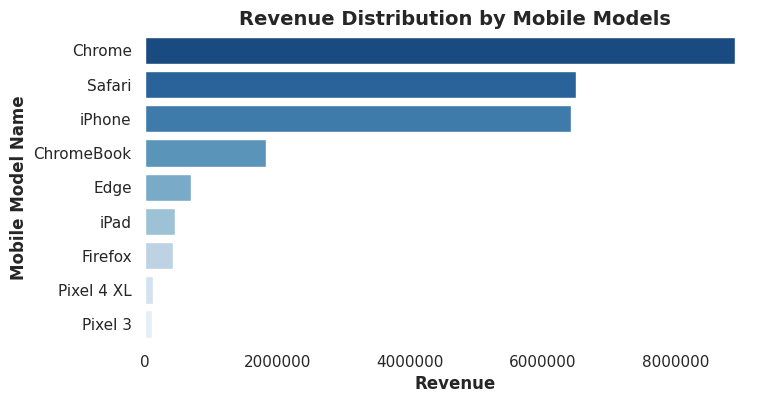

In [ ]:
revenue_by_mobile_model = df.groupby('mobile_model_name')['price'].sum().reset_index()
revenue_by_mobile_model['percentage'] = (revenue_by_mobile_model['price'] /revenue_by_mobile_model['price'].sum()) *100
revenue_by_mobile_model = revenue_by_mobile_model[revenue_by_mobile_model['mobile_model_name'] != '<Other>'].sort_values(by='percentage', ascending = False)
plt.figure(figsize=(8, 4))
sns.set_style("white")
ax = sns.barplot(
    data=revenue_by_mobile_model,
    x='price',
    y='mobile_model_name',
    palette='Blues_r',
    hue='mobile_model_name',
    legend=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style='plain', axis='x')
plt.title('Revenue Distribution by Mobile Models', fontsize=14, fontweight='bold')
plt.xlabel('Revenue', fontsize=12, fontweight='bold')
plt.ylabel('Mobile Model Name', fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True)
plt.show()

In [ ]:
revenue_analysis_device = df.groupby(['device', 'mobile_model_name'])['price'].sum().reset_index()
revenue_analysis_device['percentage'] = (revenue_analysis_device['price'] / revenue_analysis_device['price'].sum()) * 100
revenue_analysis_device.sort_values(by='percentage', ascending = False)

,device,mobile_model_name,price,percentage
1,desktop,Chrome,8899523.9,27.835602
5,desktop,Safari,6490467.1,20.300643
11,mobile,iPhone,6420776.3,20.082667
6,mobile,<Other>,5735073.6,17.937951
2,desktop,ChromeBook,1830458.7,5.725241
3,desktop,Edge,696877.3,2.179667
0,desktop,<Other>,525645.1,1.644093
13,tablet,iPad,448854.2,1.403910
4,desktop,Firefox,421066.9,1.316998
12,tablet,<Other>,274612.1,0.858922


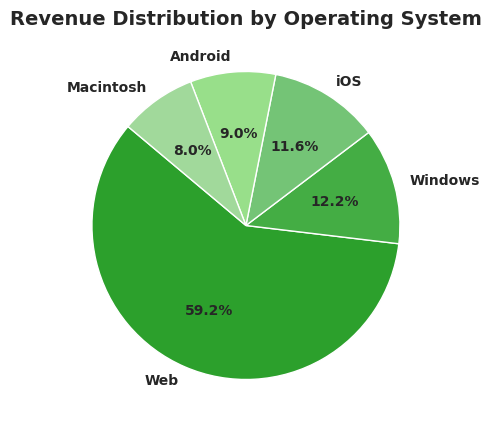

In [ ]:
revenue_by_os = df.groupby('operating_system')['price'].sum().reset_index()
revenue_by_os['percentage'] = (revenue_by_os['price'] /revenue_by_os['price'].sum()) *100
revenue_by_os = revenue_by_os[revenue_by_os['operating_system'] != '<Other>'].sort_values(by='percentage', ascending = False)
plt.figure(figsize=(7, 5))
plt.pie(
    revenue_by_os['price'],
    labels=revenue_by_os['operating_system'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#2ca02c','#44ad44','#74c476', '#98df8a',  '#a1d99b'],
    textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title('Revenue Distribution by Operating System', fontsize=14, fontweight='bold')
plt.show()

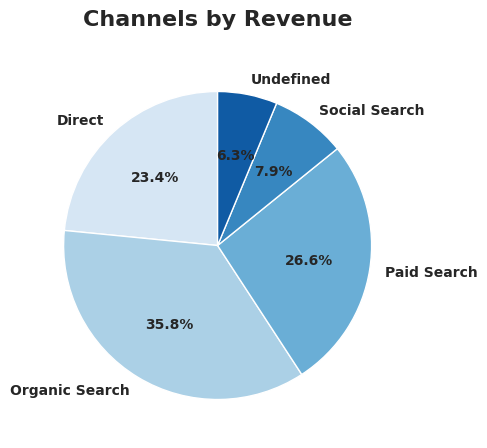

In [ ]:
revenue_by_channel = df.groupby('channel')['price'].sum().reset_index()
revenue_by_channel['percentage'] = (revenue_by_channel['price'] /revenue_by_channel['price'].sum()) *100
revenue_by_channel.sort_values(by='percentage', ascending = False)
plt.figure(figsize=(8, 5))
plt.pie(
    revenue_by_channel['price'],
    labels=revenue_by_channel['channel'],
    autopct='%1.1f%%',
    colors=sns.color_palette("Blues", len(revenue_by_channel)),
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'} )

plt.title("Channels by Revenue", fontsize=16, fontweight='bold', pad=20)
plt.show()

Desktop sessions are the primary revenue driver, accounting for 59% of total profit. Mobile devices contribute 38.7%, while tablets represent a minor share of 2.3%.  
The highest revenue is generated through Chrome (Desktop), iPhone (Mobile), and Safari (Desktop).   
Analysis of acquisition channels reveals that Organic Search is the leading source of income, responsible for 35.8% of revenue. It is followed by Paid Search (26.6%) and Direct traffic (23.4%). These three channels together drive the vast majority of sales.  

## User Engagement and Account Metrics

In [ ]:
df['is_verified'].value_counts(normalize = True)

,proportion
is_verified,
1,0.71698
0,0.28302


In [ ]:
df['is_unsubscribed'].value_counts(normalize = True)

,proportion
is_unsubscribed,
0,0.83056
1,0.16944


In [ ]:
reg_revenue = df[df['account_id'].notna()]['price'].sum()
guest_revenue = df[df['account_id'].isna()]['price'].sum()
print(f"Registered: {reg_revenue}")
print(f"Guests: {guest_revenue}")

Registered: 2582518.5
Guests: 29389212.599999998


In [ ]:
sales_from_subscibed = df.groupby('is_unsubscribed')['price'].sum().reset_index()
sales_from_subscibed['percentage'] = (sales_from_subscibed['price'] /sales_from_subscibed['price'].sum()) *100
sales_from_subscibed

,is_unsubscribed,price,percentage
0,0,2150796.9,83.282923
1,1,431721.6,16.717077


In [ ]:
country_ac = df.groupby('country')['account_id'].count().sort_values(ascending = False).reset_index()
country_ac['percentage']= (country_ac['account_id'] / country_ac['account_id'].sum())*100
country_ac.head(10)

,country,account_id,percentage
0,United States,12384,44.31562
1,India,2687,9.615316
2,Canada,2067,7.396672
3,United Kingdom,859,3.073895
4,France,553,1.978887
5,Spain,536,1.918053
6,Taiwan,500,1.789229
7,China,490,1.753444
8,Germany,490,1.753444
9,Italy,386,1.381285


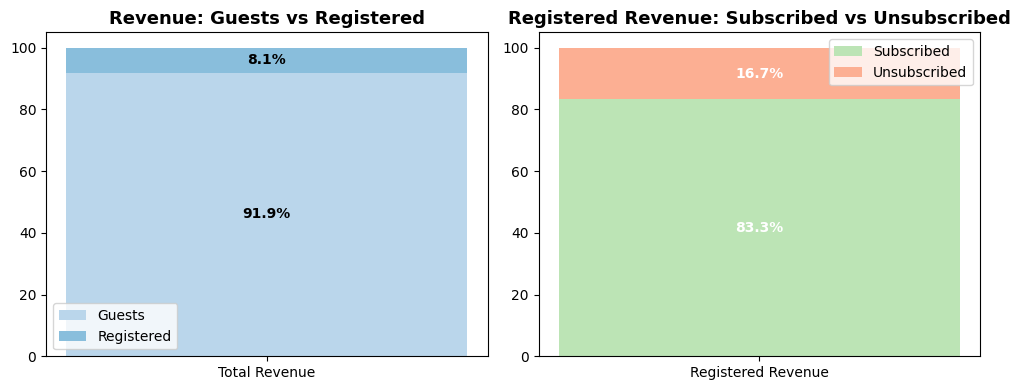

In [ ]:
total_rev = reg_revenue + guest_revenue
reg_p = (reg_revenue / total_rev) * 100
guest_p = (guest_revenue / total_rev) * 100
sub_p = sales_from_subscibed.iloc[0]['percentage']
unsub_p = sales_from_subscibed.iloc[1]['percentage']
labels_sub = ['Subscribed', 'Unsubscribed'] if sales_from_subscibed.iloc[0]['is_unsubscribed'] == 0 else ['Unsubscribed', 'Subscribed']
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['Total Revenue'], [guest_p], label='Guests', color=sns.color_palette("Blues")[1] , width=0.5)
ax[0].bar(['Total Revenue'], [reg_p], bottom=[guest_p], label='Registered', color=sns.color_palette("Blues")[2], width=0.5)
ax[0].text(0, guest_p/2, f'{guest_p:.1f}%', ha='center', va='center', fontweight='bold')
ax[0].text(0, guest_p + reg_p/2, f'{reg_p:.1f}%', ha='center', va='center', fontweight='bold')
ax[0].set_title("Revenue: Guests vs Registered", fontsize=13, fontweight='bold')
ax[0].legend()
ax[1].bar(['Registered Revenue'], [sub_p], label='Group 1', color=sns.color_palette("Greens")[1], width=0.5)
ax[1].bar(['Registered Revenue'], [unsub_p], bottom=[sub_p], label='Group 2', color = sns.color_palette("Reds")[1], width=0.5)
ax[1].text(0, sub_p/2, f'{sub_p:.1f}%', ha='center', va='center', color='white', fontweight='bold')
ax[1].text(0, sub_p + unsub_p/2, f'{unsub_p:.1f}%', ha='center', va='center', color='white', fontweight='bold')
ax[1].set_title("Registered Revenue: Subscribed vs Unsubscribed", fontsize=13, fontweight='bold')
ax[1].legend([f"Subscribed", "Unsubscribed"])

plt.tight_layout()
plt.show()

A significant majority of users (71.7%) have verified their email addresses, indicating a high level of user engagement.  
Newsletter Subscription Trends: Subscribed: 83.1%,  Unsubscribed: 16.9%    
Revenue Segmentation: Guest Revenue: 29 389 213 USD, Registered User Revenue: 2 582 518 USD.  
While the total volume is higher for guest sessions, registered users represent a more stable and reachable customer base for long-term retention.  
The Impact of Subscriptions on Revenue: Among registered users, 83.3% of revenue is generated by those who are subscribed to the newsletter. Only 16.7% of revenue comes from unsubscribed users.  
Geographic Distribution of Registered Users: The United States leads with 44.3% of all registered accounts. India follows with 9.6%. Canada holds the third position with 7.4%.

# Sales Dynamics Analysis

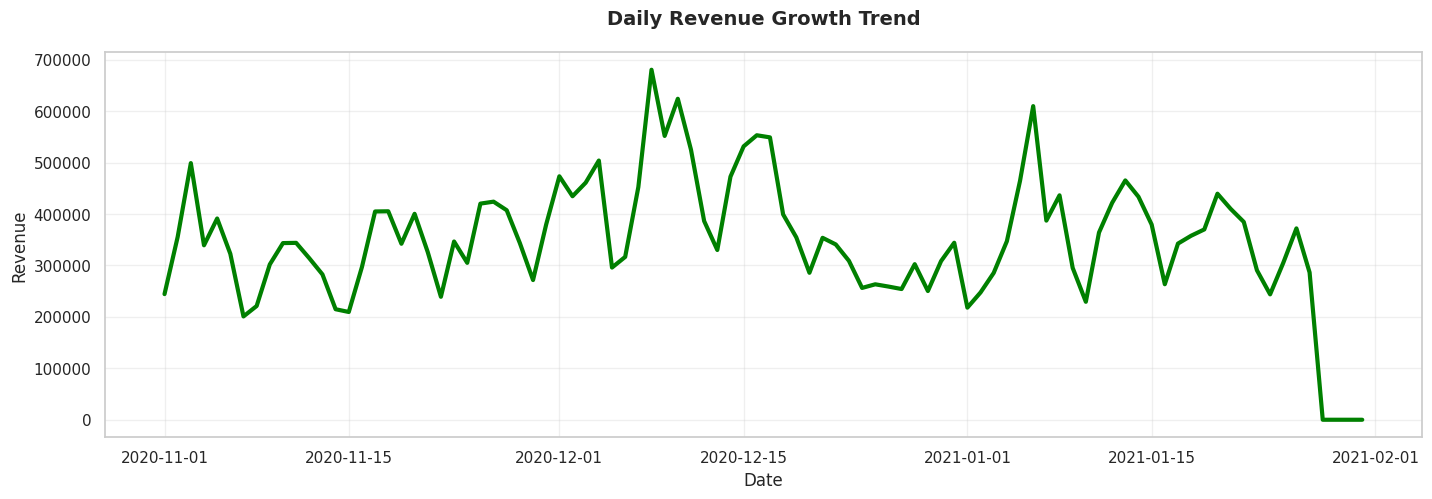

In [ ]:
df_dyn = df.groupby('date')['price'].sum().reset_index()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(17, 5))
sns.lineplot(data=df_dyn, x='date', y='price', color='green', linewidth=3)
plt.title("Daily Revenue Growth Trend", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

The peak revenue was recorded on December 8, 2020, reaching 680 510 USD. Notable growth spikes were also observed in early November and early January. A significant decline occurred during the last week of December, followed by a sharp recovery at the beginning of the new year.  
The data reveals a clear weekly seasonality in revenue patterns. However, the final days of the analyzed period are characterized by a complete absence of revenue, which may indicate a data reporting issue.

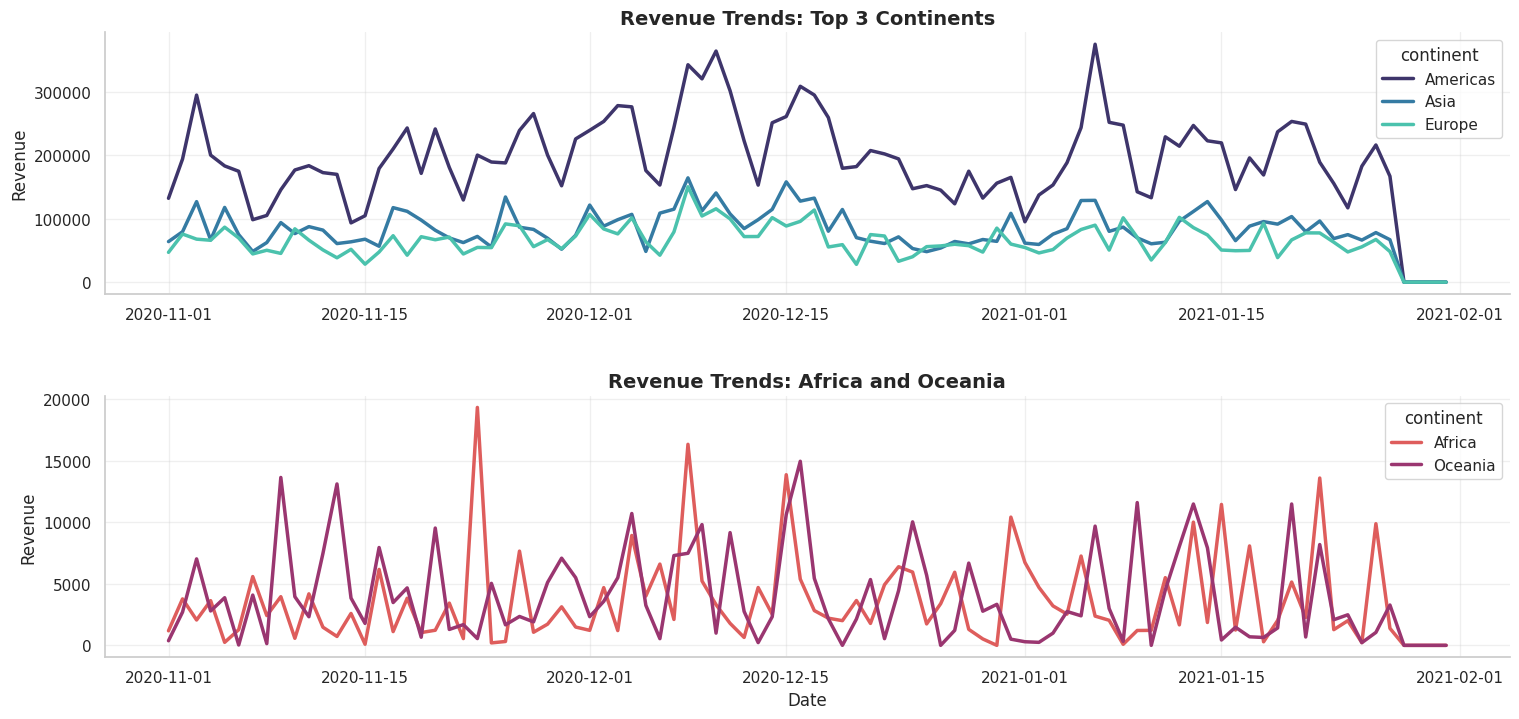

In [ ]:
df_cont = df[df['continent']!='(not set)'].groupby(['date', 'continent'])['price'].sum().reset_index()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8))
sns.lineplot(
    data=df_cont[df_cont['continent'].isin(top_3_continent.index)],
    x='date', y='price', hue='continent', palette="mako",
    ax=ax1, linewidth=2.5)
ax1.set_title("Revenue Trends: Top 3 Continents", fontsize=14, fontweight='bold')
ax1.set_ylabel("Revenue")
ax1.set_xlabel("")
ax1.grid(True, alpha=0.3)
sns.lineplot(
    data=df_cont[~df_cont['continent'].isin(top_3_continent.index)],
    x='date', y='price', hue='continent',
    ax=ax2, linewidth=2.5, palette="flare")
ax2.set_title("Revenue Trends: Africa and Oceania", fontsize=14, fontweight='bold')
ax2.set_ylabel("Revenue")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
plt.tight_layout(pad=3.0)
sns.despine()

plt.show()

The Americas region predictably generates the highest revenue. Its dynamics show pronounced weekly seasonality and revenue spikes in the first half of each month. This revenue curve closely correlates with the overall sales dynamics.   
The Asia and Europe regions follow with significantly lower figures. In most cases, Asia outperforms Europe in terms of daily revenue. Both dynamics also display clear seasonality, though their fluctuations are not as sharp as those of the Americas.  
Revenue from Oceania and Africa is substantially lower than that of the other three regions. Revenue from Oceania is more stable over time. In contrast, Africa's performance alternates between very low figures and high spikes, indicating occasional large purchases rather than consistent sales stability.

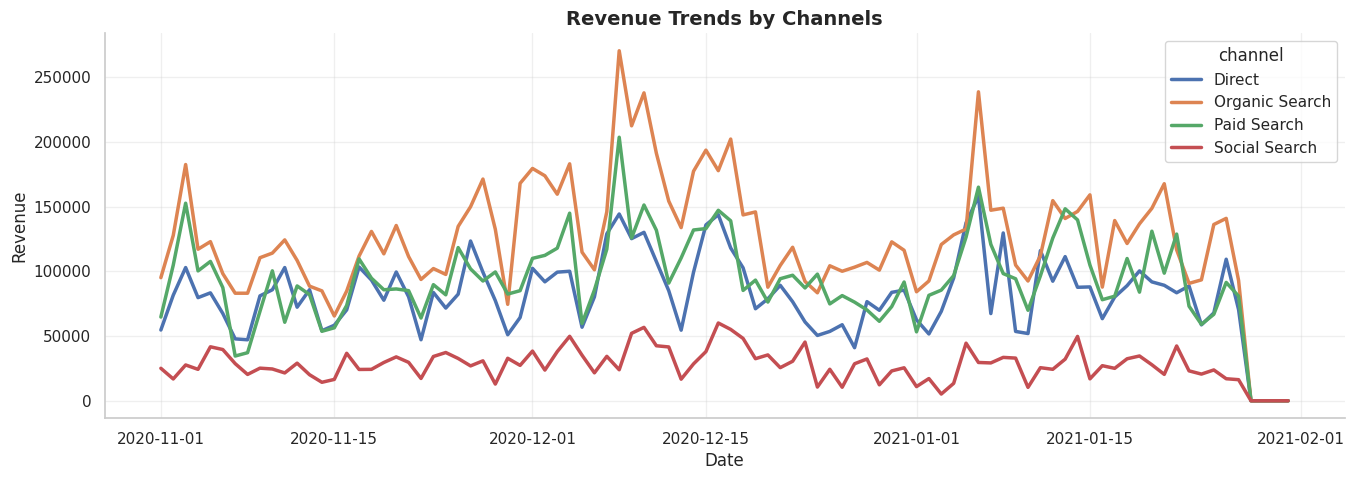

In [ ]:
df_chan = df[df['channel']!='Undefined'].groupby(['date', 'channel'])['price'].sum().reset_index()
plt.figure(figsize=(16, 5))
sns.lineplot(
    data = df_chan, x='date', y='price', hue='channel', palette="deep", linewidth=2.5)
plt.title("Revenue Trends by Channels", fontsize=14, fontweight='bold')
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

Revenue performance across different channels closely correlates with the overall revenue dynamics, as evidenced by synchronized increases and decreases. Organic, Direct, and Paid channels follow a similar pattern, reflecting a uniform development across these avenues.
Organic Search generates the highest revenue, followed by Paid Search, and then Direct traffic. Social Media contributes the least amount of revenue. However, its performance is characterized by stability, with a constant trend that lacks both high spikes and sharp declines.

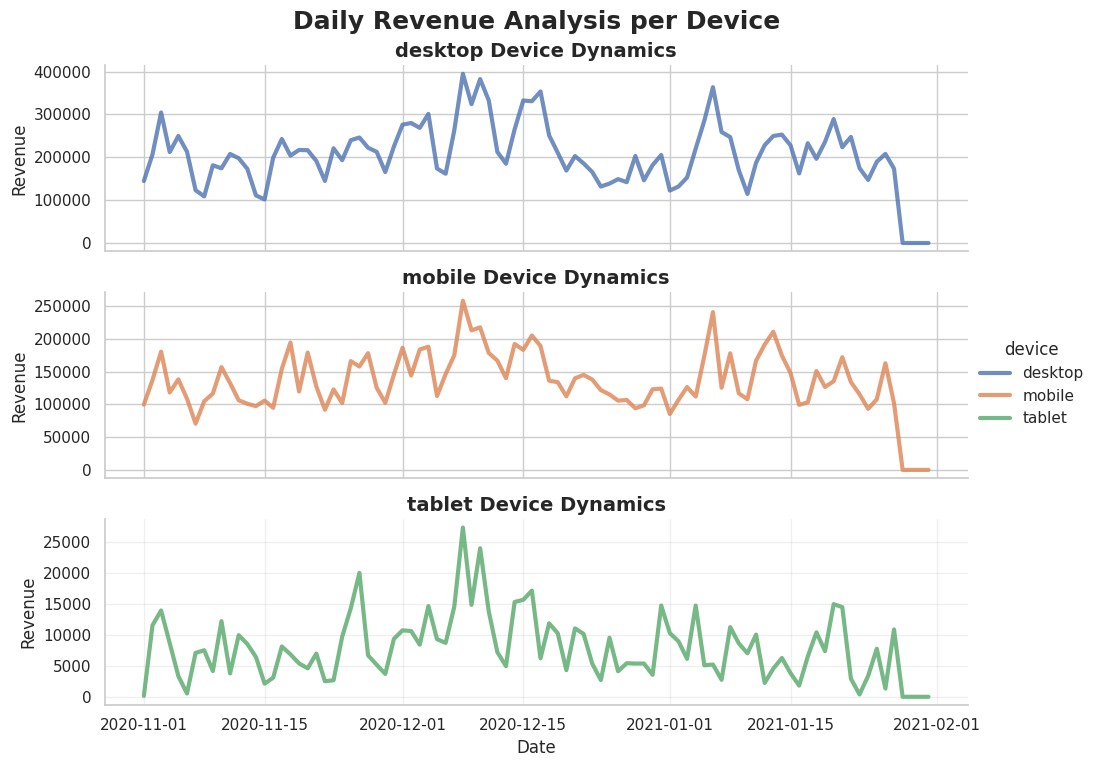

In [ ]:
df_dev = df.groupby(['date', 'device'])['price'].sum().reset_index()
g = sns.relplot(
    data=df_dev,
    x='date',
    y='price',
    row='device',
    hue='device',
    kind='line',
    palette='deep',
    linewidth=3,
    alpha=0.8,
    height=2.5,
    aspect=4,
    facet_kws={'sharey': False})
g.set_titles(row_template="{row_name} Device Dynamics", size=14, fontweight='bold')
g.set_axis_labels("Date", "Revenue")
g.fig.suptitle("Daily Revenue Analysis per Device",
               fontsize=18, fontweight='bold', y=1.02)
plt.grid(True, alpha=0.3)
plt.show()

The majority of revenue is generated through Desktop and Mobile devices. Their dynamics closely correlate with the overall revenue trends and consistently maintain a clear weekly seasonality.  
In contrast, Tablets show significantly lower revenue figures. The tablet segment is characterized by more frequent fluctuations and higher volatility, indicating that purchases made via tablets are less stable compared to other device categories.

# Summary Tables

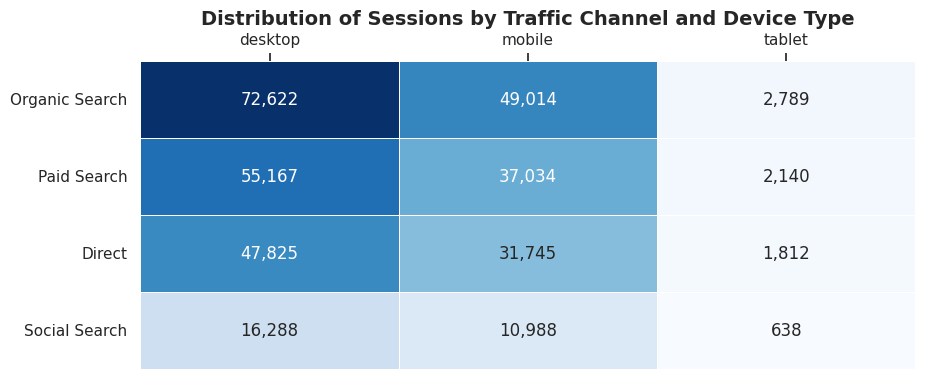

In [ ]:
channel_device_sess= df[df['channel'] != 'Undefined'].pivot_table(index = 'channel', columns = 'device', values = 'ga_session_id', aggfunc = 'count').sort_values(by='desktop', ascending = False).fillna(0)
plt.figure(figsize=(10, 4))
channel_device_sess = channel_device_sess.astype(float)
ax1 = sns.heatmap(channel_device_sess, cmap="Blues", annot=True, fmt=",.0f",  linewidths=.5, cbar=False)
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')
plt.title("Distribution of Sessions by Traffic Channel and Device Type", fontsize=14, fontweight='bold')
plt.ylabel("")
plt.xlabel("")
plt.show()


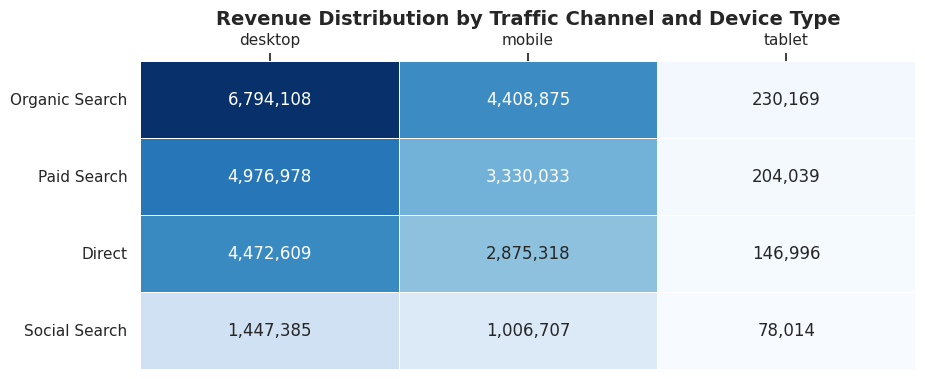

In [ ]:
channel_device_sales = df[df['channel'] != 'Undefined'].pivot_table(index = 'channel', columns = 'device', values = 'price', aggfunc = 'sum').sort_values(by='desktop', ascending = False)
plt.figure(figsize=(10, 4))
ax = sns.heatmap(channel_device_sales, annot=True, fmt=",.0f", cmap="Blues", linewidths=.5, cbar=False)
plt.ylabel("")
plt.xlabel("")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.title("Revenue Distribution by Traffic Channel and Device Type", fontsize=14, fontweight='bold')
plt.show()

The distribution of sessions and revenue shows a strong positive correlation, confirming that high-traffic segments are effectively converting into sales. The Desktop category, specifically through Organic Search, represents the primary engine of growth, accounting for the highest volume of both sessions and total revenue.  
Organic Search remains the most dominant channel regardless of the device type. Paid Search follows as a strong second, demonstrating a healthy return on advertising spend.  
The Mobile segment shows significant activity across all channels, reinforcing the importance of mobile optimization for the Organic and Paid Search funnels.  
Tablets and Social Search contribute the least to the overall mix, suggesting these areas either serve a niche audience or represent an opportunity for future growth.  

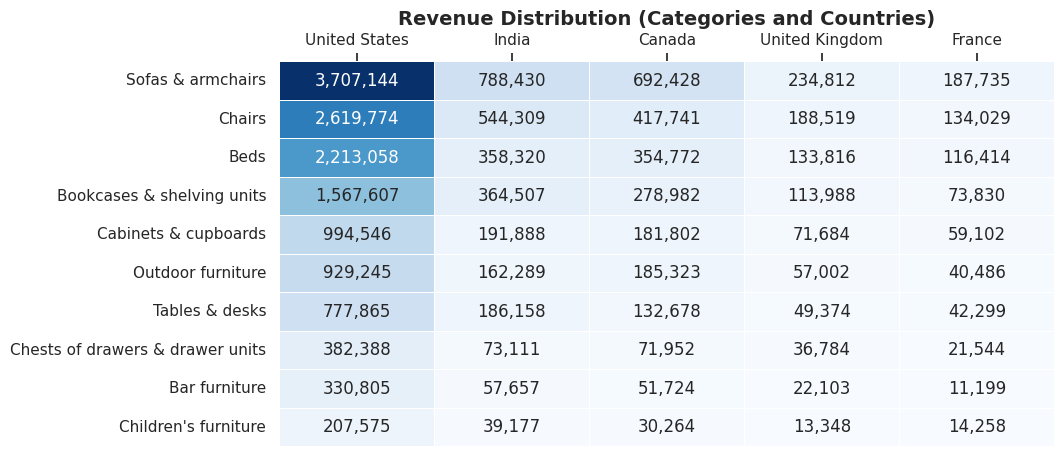

In [ ]:
df_for_pt = df[(df['category'].isin(top_10_category.index)) & (df['country'].isin(top_5_country.index))]
country_category = df_for_pt.pivot_table(index = 'category', columns = 'country', values = 'price', aggfunc = 'sum')
country_category  = country_category.loc[top_10_category.index, top_5_country.index]
plt.figure(figsize=(10, 5))
ax = sns.heatmap(country_category, annot=True, fmt=",.0f", cmap="Blues", linewidths=.5, cbar=False)
plt.ylabel("")
plt.xlabel("")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.title("Revenue Distribution (Categories and Countries)", fontsize=14, fontweight='bold')
plt.show()


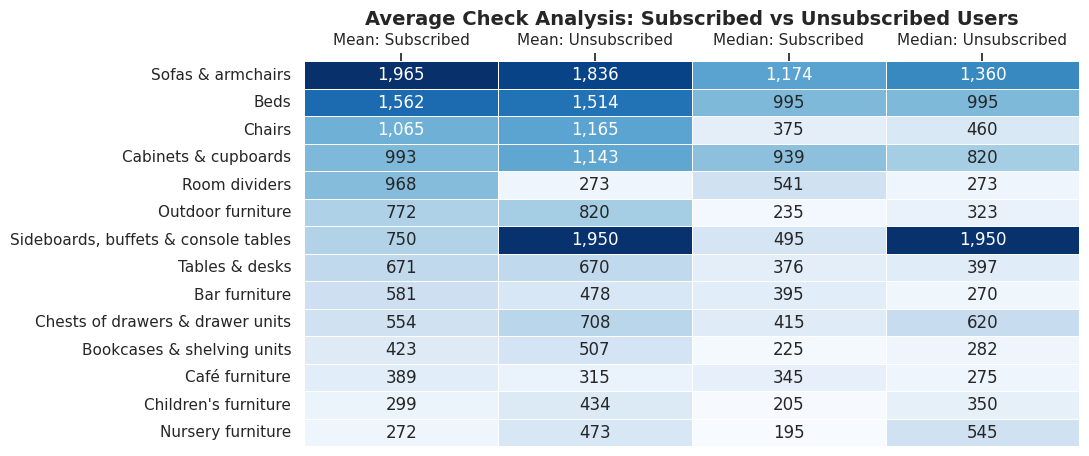

In [ ]:
avg_check_pt = df.pivot_table(index='category', columns='is_unsubscribed', values='price', aggfunc=['mean', 'median']).sort_values(by=('mean', 0.0), ascending = False)
avg_check_pt.columns = ['Mean: Subscribed', 'Mean: Unsubscribed', 'Median: Subscribed', 'Median: Unsubscribed']

plt.figure(figsize=(10, 5))
ax = sns.heatmap(avg_check_pt, annot=True, fmt=",.0f", cmap="Blues", linewidths=.5, cbar=False)
plt.ylabel("")
plt.xlabel("")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.title("Average Check Analysis: Subscribed vs Unsubscribed Users", fontsize=14, fontweight='bold')
plt.show()


This analysis examines the average check across the top categories for subscribed and unsubscribed registered users. A key finding is the significant discrepancy between mean and median values, particularly among subscribed users.  
**Subscribed Users**: In the top categories - specifically Sofas & Armchairs, Beds, Chairs, and Outdoor Furniture - the mean substantially exceeds the median. This indicates a distribution characterized by a large volume of smaller transactions paired with a few exceptionally high-value purchases.  
**Unsubscribed Users**: The top three categories by value are Sideboards, Buffets & Console Tables, Sofas & Armchairs, and Beds. Interestingly, for the Sideboards, Buffets & Console Tables category among unsubscribed users, the mean and median are identical. This suggests a very narrow price range and a high level of consistency in purchase behavior. For most other categories, the trend of the mean exceeding the median persists, confirming that the majority of revenue comes from lower-priced items, while a small segment of premium purchases drives the average up.

# Relationship Analysis

## Session Volume and Revenue Correlation

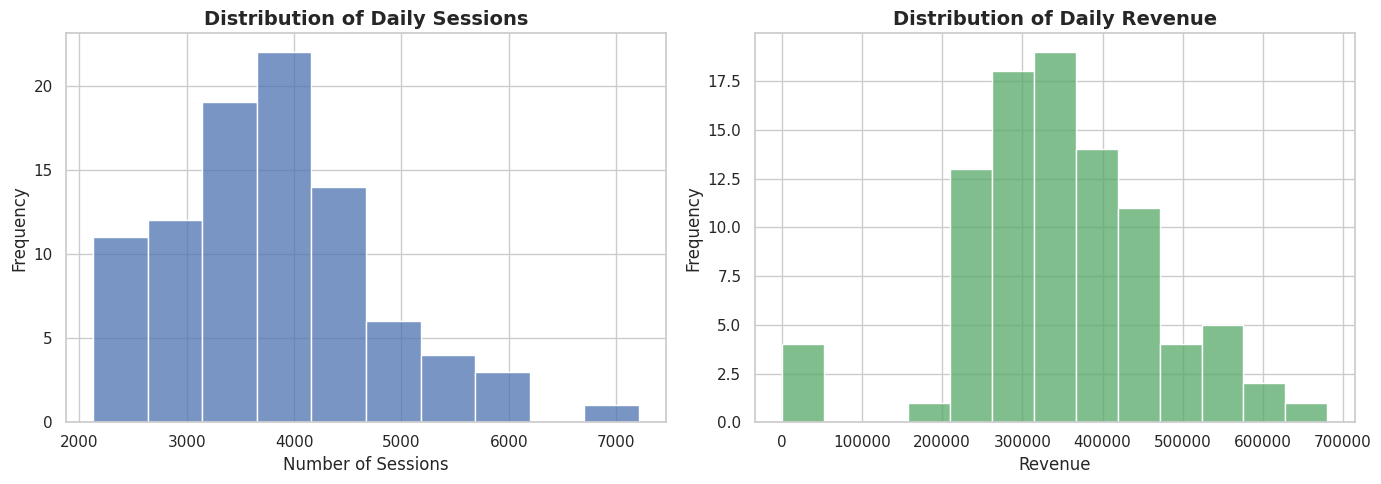

In [ ]:
for_scatter = df.groupby('date').agg({'ga_session_id': 'count', 'price': 'sum'}).reset_index()
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(for_scatter['ga_session_id'], color='#4c72b0', ax=axes[0])
axes[0].set_title('Distribution of Daily Sessions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Sessions')
axes[0].set_ylabel('Frequency')
sns.histplot(for_scatter['price'], color='#55a868', ax=axes[1])
axes[1].set_title('Distribution of Daily Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

P-value Pearson: 0.00000
Pearson Correlation Coefficient: 0.7911
P-value Spearman : 0.00000
Spearman Correlation: 0.8653
P-value Kendall : 0.00000
Kendall Correlation: 0.717666930923723


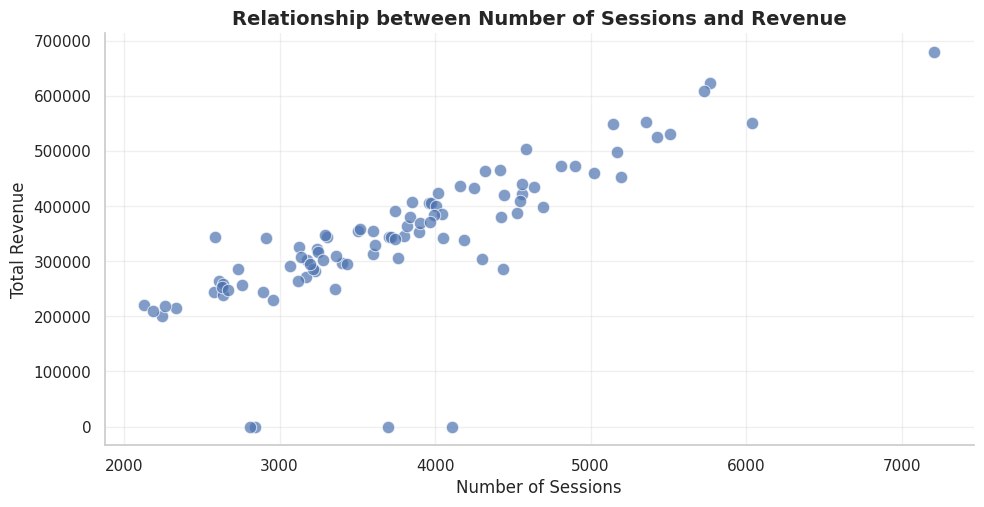

In [ ]:
for_scatter = df.groupby('date').agg({'ga_session_id': 'count', 'price': 'sum'}).reset_index()
sns.relplot(data=for_scatter, x='ga_session_id', y='price', color='#4c72b0', alpha=0.7, s=80, height=5, aspect=2 )
corr_coefficient, p_value = pearsonr(for_scatter['ga_session_id'], for_scatter['price'])
print(f"P-value Pearson: {p_value:.5f}")
print(f"Pearson Correlation Coefficient: {corr_coefficient:.4f}")
_,p_value =spearmanr(for_scatter['ga_session_id'], for_scatter['price'])
print( f"P-value Spearman : {p_value:.5f}")
spearman_corr = for_scatter['ga_session_id'].corr(
    for_scatter['price'], method="spearman")
print(f"Spearman Correlation: {spearman_corr:.4f}")
_, p_value = kendalltau(for_scatter['ga_session_id'], for_scatter['price'])
print( f"P-value Kendall : {p_value:.5f}")
kendall_corr = for_scatter['ga_session_id'].corr(
    for_scatter['price'], method="kendall")
print(f"Kendall Correlation: {kendall_corr}")
plt.title('Relationship between Number of Sessions and Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Number of Sessions')
plt.ylabel('Total Revenue')
plt.grid(True, alpha=0.3)
plt.show()

The scatter plot demonstrates a clear linear relationship and a strong positive correlation between the number of sessions and total revenue: as session volume increases, revenue tends to grow proportionally.  
There are specific instances where a high number of sessions resulted in zero revenue. These anomalies could indicate tracking issues, technical glitches during checkout, or specific days with high traffic but no conversions.
The data also shows data points with exceptionally high session counts and revenue, representing peak performance days.  
Despite the presence of outliers, the majority of data points are tightly clustered along the upward trend line, confirming that session volume remains a reliable predictor of financial success for the business.
The visual inspection of daily distributions reveals that both Sessions and Revenue are not perfectly normal, exhibiting a distinct right-side skew (long tails toward higher values).
Additionally, the revenue distribution contains zero-value outliers despite high session counts. While the Pearson coefficient indicates a strong linear trend, its reliability may be slightly compromised by extreme outliers and non-normal distribution. To ensure robustness, non-parametric methods like Spearman and Kendall rank correlations were also calculated:  
*   Pearson (0.7911): Confirms a strong linear relationship.  
*   Spearman (0.8653): Being higher than Pearson, it proves that the monotonic upward trend is very consistent and less affected by those "zero-revenue" days.
*   Kendall Tau (0.7177): Provides the most conservative and robust estimate.   Since it measures the strength of the association based on the concordant and discordant pairs of data.  

Statistical testing confirms a strong and significant relationship between daily sessions and revenue (p < 0.001). The high values of both Spearman and Kendall coefficients prove that the upward trend is consistent and robust, even when accounting for days with unusual traffic or zero sales.

## Regional Revenue Interdependence

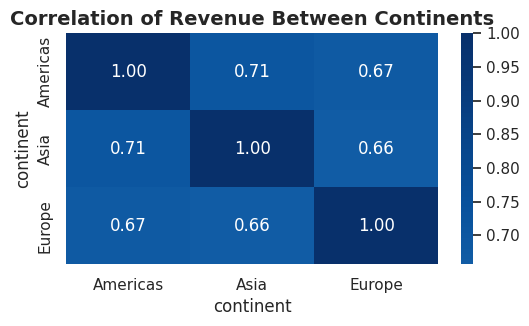

In [ ]:
df_cont_d = df[df['continent'].isin(top_3_continent.index)]
pt_cont = df_cont_d.pivot_table(index = 'date', columns = 'continent', values = 'price', aggfunc = 'sum')
correlation_matrix = pt_cont.corr(method='spearman')

plt.figure(figsize=(6, 3))
sns.heatmap(correlation_matrix, annot=True,  cmap='Blues', center=0, fmt='.2f')
plt.title('Correlation of Revenue Between Continents', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
p_matrix = pt_cont.corr(method=lambda x, y: spearmanr(x, y)[1])
print("Statistical Significance Matrix (P-values)")
p_matrix.round(4).style.background_gradient(cmap='Blues_r')

Statistical Significance Matrix (P-values)


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.000000,0.000000
Asia,0.000000,1.000000,0.000000
Europe,0.000000,0.000000,1.000000


The analysis reveals a strong positive correlation between the revenue streams of the three key regions. The most prominent relationship is observed between the Americas and Asia (0.71), while Asia-Europe (0.66) and Americas-Europe (0.67) also demonstrate significant synchronization in daily performance.  
To validate these findings, p-value testing was conducted, with all results falling well below the 0.05 threshold. This confirms that the observed inter-regional dependencies are statistically significant and not the result of random fluctuations. These results suggest that global sales trends are driven by shared factors, indicating highly synchronized market behavior across these continents.

## Inter-Channel Revenue Correlation

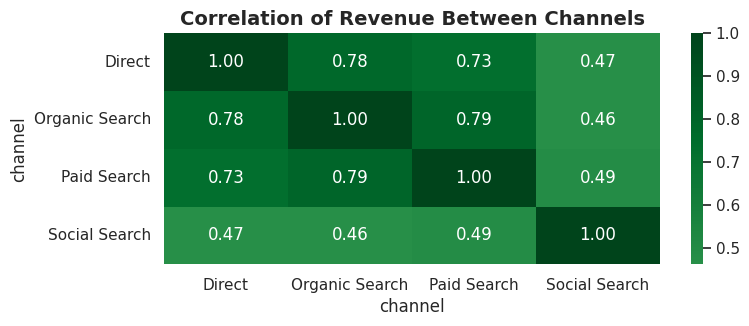

In [ ]:
df_channel = df[df['channel'] != 'Undefined']
pt_channel = df_channel.pivot_table(index = 'date', columns = 'channel', values = 'price', aggfunc = 'sum')
correlation_matrix_2 = pt_channel.corr(method='spearman')

plt.figure(figsize=(8, 3))
sns.heatmap(correlation_matrix_2, annot=True,  cmap='Greens', center=0, fmt='.2f')
plt.title('Correlation of Revenue Between Channels', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
p_matrix = pt_channel.corr(method=lambda x, y: spearmanr(x, y)[1])
print("Statistical Significance Matrix (P-values)")
p_matrix.round(4).style.background_gradient(cmap='Greens_r')

Statistical Significance Matrix (P-values)


channel,Direct,Organic Search,Paid Search,Social Search
channel,,,,
Direct,1.000000,0.000000,0.000000,0.000000
Organic Search,0.000000,1.000000,0.000000,0.000000
Paid Search,0.000000,0.000000,1.000000,0.000000
Social Search,0.000000,0.000000,0.000000,1.000000


The analysis identifies a strong synchronization between Organic Search, Paid Search, and Direct channels. Specifically, the correlation between Organic and Paid Search reaches 0.79, while Organic-Direct - 0.78, and Direct-Paid - 0.73 also show high dependency. This suggests that these primary channels are driven by the same baseline demand and global marketing efforts.  
In contrast, Social Search displays a much weaker correlation with other channels (under 0.50), indicating a distinct sales dynamic. This isolation suggests that social media traffic follows independent trends, likely influenced by specific social campaigns rather than general search behavior.  
All calculated p-values are 0.0000, confirming that these correlations - both strong and weak - are statistically significant and represent consistent patterns in the data.

## Cross-Category Revenue Interdependence

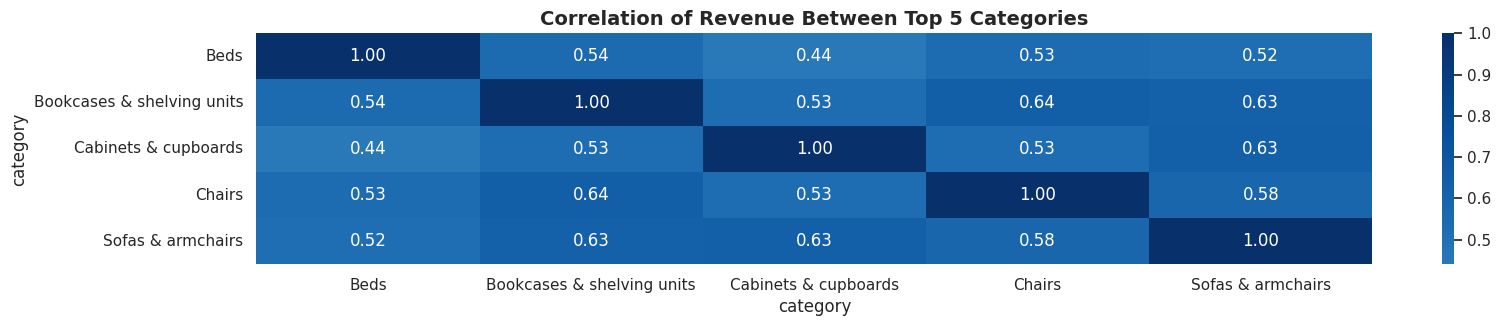

In [ ]:
top_5_category = df.groupby('category')['price'].sum().sort_values(ascending = False).head()
df_categ = df[df['category'].isin(top_5_category.index)]
pt_categ = df_categ.pivot_table(index = 'date', columns = 'category', values = 'price', aggfunc = 'sum')
correlation_matrix = pt_categ.corr(method='spearman')

plt.figure(figsize=(18, 3))
sns.heatmap(correlation_matrix, annot=True,  cmap='Blues', center=0, fmt='.2f')
plt.title('Correlation of Revenue Between Top 5 Categories', fontsize=14, fontweight='bold')
plt.show()


In [ ]:
p_matrix = pt_categ.corr(method=lambda x, y: spearmanr(x, y)[1])
print("Statistical Significance Matrix (P-values)")
p_matrix.round(4).style.background_gradient(cmap='Blues_r')

Statistical Significance Matrix (P-values)


category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000000,0.000000,0.000000,0.000000,0.000000
Bookcases & shelving units,0.000000,1.000000,0.000000,0.000000,0.000000
Cabinets & cupboards,0.000000,0.000000,1.000000,0.000000,0.000000
Chairs,0.000000,0.000000,0.000000,1.000000,0.000000
Sofas & armchairs,0.000000,0.000000,0.000000,0.000000,1.000000


The correlation analysis among the top 5 product categories reveals moderate positive dependencies, with coefficients ranging from 0.44 to 0.64. These findings suggest synchronized purchasing patterns across different furniture segments.  
The most significant correlations are observed between Chairs and Bookcases & shelving units (0.64), as well as between Sofas & armchairs and Bookcases & shelving units (0.63). This indicates that customers frequently purchase seating and storage solutions together, likely when furnishing living or office spaces.  
Beds show the weakest relationship with Cabinets & cupboards (0.44), suggesting that bedroom furniture acquisitions often follow a separate purchasing cycle.
All results are statistically significant (p-value < 0.05), confirming that these trends are consistent. This provides a strong data-driven foundation for cross-selling strategies: customers purchasing items from one of these correlated categories can be effectively targeted with recommendations for products from the other linked categories.

## Registered and Guest Purchase Correlation

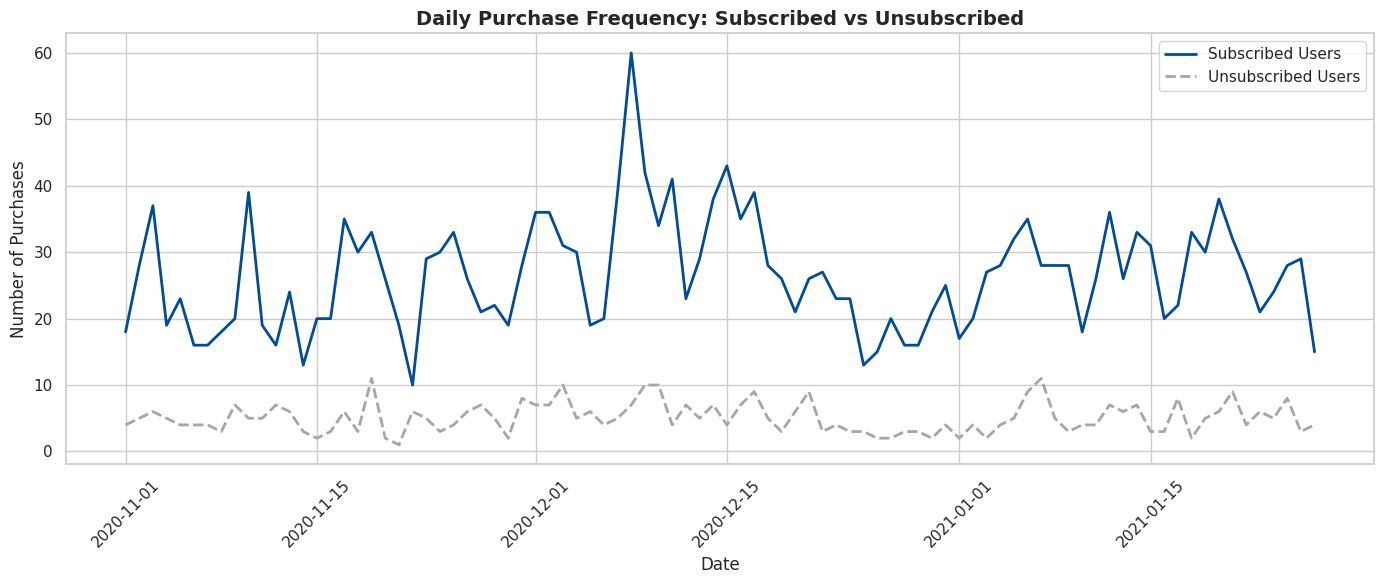

In [ ]:
pt_sub = df.pivot_table(index = 'date', columns ='is_unsubscribed', values = 'price', aggfunc = 'count')
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")
plt.plot(pt_sub.index, pt_sub[0], label='Subscribed Users', color='#004c99', linewidth=2)
plt.plot(pt_sub.index, pt_sub[1], label='Unsubscribed Users', color='#a6a6a6', linewidth=2, linestyle='--')
plt.title('Daily Purchase Frequency: Subscribed vs Unsubscribed', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
_,p_value =spearmanr(pt_sub[0], pt_sub[1])
print( f"P-value Spearman : {p_value:.5f}")
spearman_corr = pt_sub[0].corr(pt_sub[1], method="spearman")
print(f"Spearman Correlation: {spearman_corr:.4f}")

P-value Spearman : 0.00002
Spearman Correlation: 0.4393


This analysis compares the daily purchase trends of two distinct segments: subscribed and unsubscribed users. The **goal** was to determine if both groups follow the same purchasing cycle or if they behave independently.
A Spearman correlation of 0.44 indicates a moderate relationship between the two time series. This suggests that while there is some shared seasonality, the two groups do not react identically to market events.
The relatively low correlation, combined with the high volatility of the Subscribed group, suggests that subscribers are driven by unique engagement channels (such as direct email marketing) that do not reach or affect the unsubscribed segment.
The visual evidence shows that subscribed users consistently maintain a significantly higher volume of transactions. The presence of sharp spikes in the subscribed group - which are absent in the unsubscribed trend-highlights the effectiveness of the subscription channel in generating incremental sales.
The p-value (0.00002) confirms that the difference and the observed correlation between these two trends are statistically significant.

# Comparative Analysis of Segmented Performance Metrics

## Revenue Significance by Subscription Status

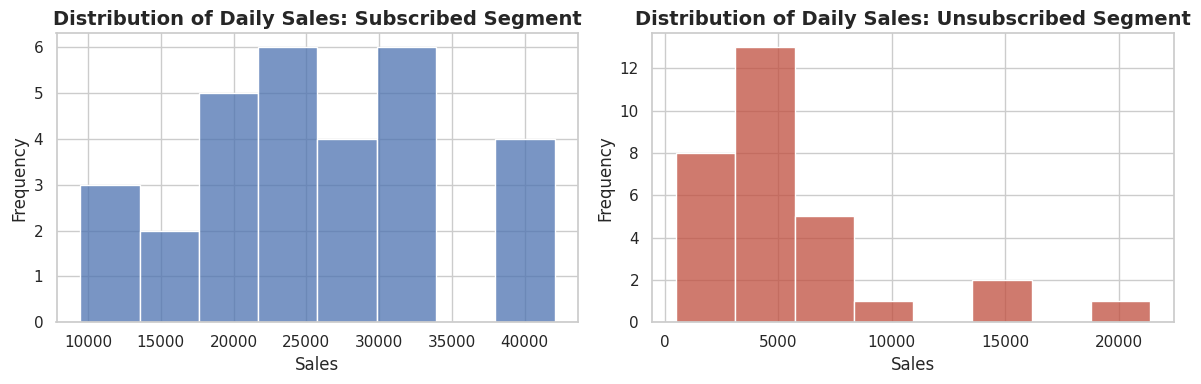

In [ ]:
pt_sub_sales = df.pivot_table(index = 'date', columns ='is_unsubscribed', values = 'price', aggfunc = 'sum').reset_index()
sample_data = pt_sub_sales.sample(n=30, random_state=1)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample_data[0], color='#4c72b0', ax=axes[0], bins = 8)
axes[0].set_title('Distribution of Daily Sales: Subscribed Segment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
sns.histplot(sample_data[1], color='#C04E3E', ax=axes[1], bins = 8)
axes[1].set_title('Distribution of Daily Sales: Unsubscribed Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sales')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
u_stat, p_value = mannwhitneyu(sample_data[0], sample_data[1])
print(f"U-statistic: {u_stat}, p-value: {p_value:0.5f}")
median_sub = pt_sub_sales[0].median()
median_unsub = pt_sub_sales[1].median()
diff_percent = ((median_sub - median_unsub) / median_unsub) * 100
print(f"Median Sales (Subscribed): {median_sub:.2f}")
print(f"Median Sales (Unsubscribed): {median_unsub:.2f}")
print(f"Revenue Uplift from Subscription: {diff_percent:.1f}%")


U-statistic: 884.0, p-value: 0.00000
Median Sales (Subscribed): 23863.80
Median Sales (Unsubscribed): 3823.00
Revenue Uplift from Subscription: 524.2%


To compare daily revenue between users who are subscribed to the email newsletter and those who are unsubscribed. The **goal** is to determine if the difference in their spending is statistically significant, in order to justify further investment in customer retention strategies.  
A synchronized random sample (n=30) was drawn from daily sales to ensure both groups are compared under identical market conditions.The Mann-Whitney U test was applied due to the non-normal distribution of sales data. Significance: p < 0.001, confirming a statistically significant difference between segments. Subscription status is identified as a statistically significant determinant of revenue volume. Subscribed users represent the high-performing core of the customer base (30 000 USD). Unsubscribed users are restricted to a low-revenue bracket, rarely exceeding 10 000 USD.  
Capital investment in customer retention programs is recommended. Minimizing churn is a direct and data validated method for maintaining long-term revenue stability and protecting the existing sales base.



## Traffic Channel Volume and Significance

In [ ]:
pt_chan_s_cnt = df.pivot_table(index = 'date', columns ='channel', values = 'ga_session_id', aggfunc = 'count').reset_index()
f_stat, p_value = f_oneway(pt_chan_s_cnt['Direct'], pt_chan_s_cnt['Organic Search'], pt_chan_s_cnt['Paid Search'], pt_chan_s_cnt['Social Search'], pt_chan_s_cnt['Undefined'])
print(f"F-statistic ANOVA: {f_stat}")
print(f"P-value ANOVA: {p_value:0.5f}")
stat, p_value = kruskal(pt_chan_s_cnt['Direct'], pt_chan_s_cnt['Organic Search'], pt_chan_s_cnt['Paid Search'], pt_chan_s_cnt['Social Search'], pt_chan_s_cnt['Undefined'])
print(f"Kruskal-Wallis statistic: {stat:0.5f}")
print(f"P-value: {p_value:0.5f}")
medians = pt_chan_s_cnt[['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']].median()
means = pt_chan_s_cnt[['Direct', 'Organic Search', 'Paid Search', 'Social Search', 'Undefined']].mean()
comparison_df = pd.DataFrame({'Median': medians, 'Mean': means}).sort_values(by='Median', ascending=False)
comparison_df

F-statistic ANOVA: 439.7675316990713
P-value ANOVA: 0.00000
Kruskal-Wallis statistic: 368.98057
P-value: 0.00000


,Median,Mean
channel,,
Organic Search,1329.0,1352.445652
Paid Search,989.0,1025.445652
Direct,869.5,884.586957
Social Search,308.0,303.413043
Undefined,229.0,233.51087


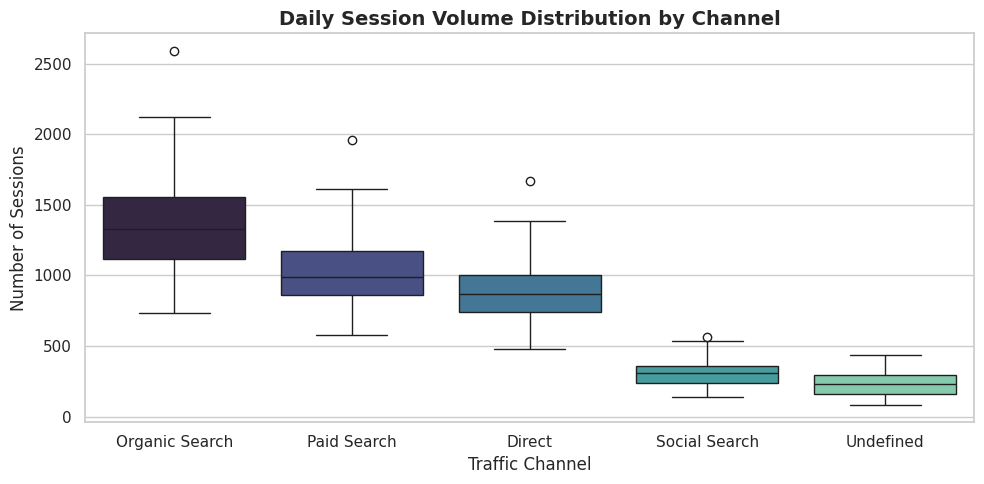

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

channels_to_plot = ['Organic Search', 'Paid Search', 'Direct', 'Social Search', 'Undefined']
sns.boxplot(data=pt_chan_s_cnt[channels_to_plot], palette="mako")

plt.title('Daily Session Volume Distribution by Channel', fontsize=14, fontweight='bold')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Traffic Channel', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The **goal** of this analysis is to compare session volumes across different traffic channels and determine if the differences are statistically significant to optimize marketing resource allocation. This involves identifying which channels consistently drive higher engagement and justifying shifts in strategy based on data-driven evidence.  
The analysis employed both One-Way ANOVA to compare mean values and the Kruskal-Wallis test to evaluate differences in medians. Both tests yielded a p-value significantly lower than 0.05, confirming statistically significant differences between the groups. This proves that the variance in channel performance is not accidental and represents fundamental differences in traffic acquisition.  
Organic Search is the most successful channel with a median of 1329 sessions, followed by Paid Search (989), Direct (867), Social Search (308), and Undefined (229).  
Organic Search is statistically confirmed as the primary driver of traffic and should remain the core of the marketing strategy. Paid Search demonstrates high engagement levels, which justifies the current budget and investment in this channel. Direct sessions show strong results, indicating high brand recognition and a loyal user base. Social Search requires further development as a channel for increasing user acquisition, given its currently low performance.

## Regional Organic Traffic Share Comparison

Z-statistic: -0.2895
P-value: 0.77219


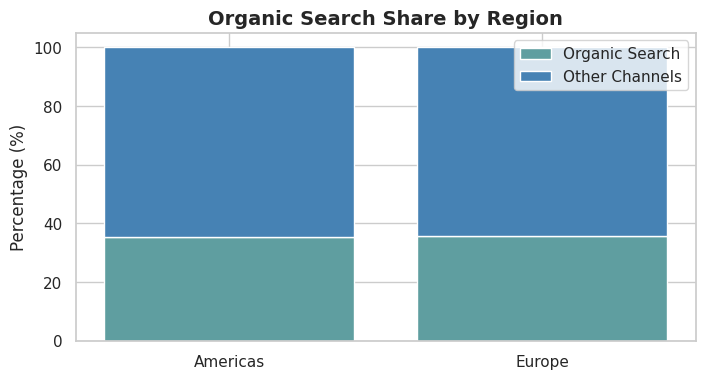

In [ ]:
eu_am_df = df[(df['channel'] == 'Organic Search') & (df['continent'].isin(["Europe", "Americas"] ))]
pt_organic = eu_am_df.pivot_table(index = 'continent', columns= 'channel', values = ['ga_session_id', 'name'], aggfunc = {'ga_session_id': 'count', 'name': 'count'})
total_sessions_by_reg = df.groupby('continent')['ga_session_id'].count()
org_amer = pt_organic.loc['Americas', ('ga_session_id', 'Organic Search')]
org_eu = pt_organic.loc['Europe', ('ga_session_id', 'Organic Search')]

total_am = total_sessions_by_reg['Americas']
total_eu = total_sessions_by_reg['Europe']

z_stat, p_value = sm.stats.proportions_ztest([org_amer, org_eu ], [total_am, total_eu ])
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.5f}")

shares = {
    'Americas': [org_amer / total_am * 100, (total_am - org_amer) / total_am * 100],
    'Europe': [org_eu / total_eu * 100, (total_eu - org_eu) / total_eu * 100] }

labels = ['Americas', 'Europe']
organic_shares = [shares['Americas'][0], shares['Europe'][0]]
other_shares = [shares['Americas'][1], shares['Europe'][1]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, organic_shares, label='Organic Search', color='cadetblue')
ax.bar(labels, other_shares, bottom=organic_shares, label='Other Channels', color='steelblue')
ax.set_ylabel('Percentage (%)')
ax.set_title('Organic Search Share by Region', fontsize=14, fontweight='bold')
ax.legend()

plt.show()

The **goal** of this analysis is to determine whether there is a statistically significant difference in the share of Organic Search sessions between the Americas and Europe regions.  
A Z-test for proportions was used to compare the relative weight of organic traffic in the total session volume across both geographic segments. The test resulted in a p-value greater than 0.05, indicating that the observed difference is not statistically significant.  
The share of organic sessions is consistent across both regions, suggesting a uniform level of user engagement through the organic channel. No region-specific adjustments to the organic acquisition model are required at this stage, allowing marketing efforts to remain focused on global channel growth.


## Regional Organic Conversion Rate Comparison

 Session Count: 349545.
Order Count: 33538


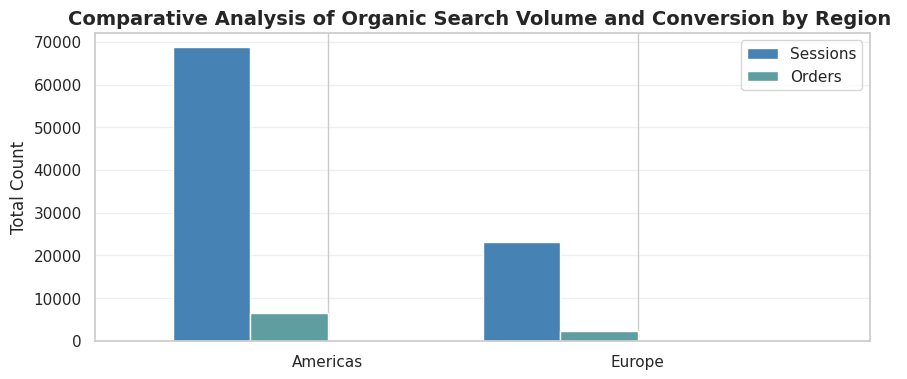

In [ ]:
pt_organic = eu_am_df.pivot_table(index = 'continent', columns= 'channel', values = ['ga_session_id', 'name'], aggfunc = {'ga_session_id': 'count', 'name': 'count'})
total_session = df['ga_session_id'].count()
total_order = df['price'].count()
print(f' Session Count: {total_session}.\nOrder Count: {total_order}')

pt_organic['percentage_session'] = (pt_organic[('ga_session_id', 'Organic Search')] / total_session) * 100
pt_organic['percentage_order_cnt'] = (pt_organic[('name', 'Organic Search')] / total_order) * 100

ax = pt_organic.plot(kind='bar', color=['steelblue', 'cadetblue'], figsize=(10, 4), width=1.0,  rot=0)
ax.set_title('Comparative Analysis of Organic Search Volume and Conversion by Region ', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Count')
ax.set_xlabel('')
ax.legend(['Sessions', 'Orders'])
ax.grid(True, axis='y', alpha=0.3)

plt.show()

In [ ]:
order_am = pt_organic.loc['Americas', ('name', 'Organic Search')]
order_eu = pt_organic.loc['Europe', ('name', 'Organic Search')]

z_stat, p_value = sm.stats.proportions_ztest([order_am, order_eu], [org_amer, org_eu])
print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

Z-statistic: -0.5859242709562077
P-value: 0.5579264062749942


The **goal** of this analysis is to compare conversion rates between the Americas and Europe for the Organic Search channel to determine if the geographic difference in user behavior is statistically significant.  
A Z-test for proportions was conducted to evaluate the relationship between the number of orders and total sessions across the two regions. There is no statistically significant difference in conversion rates between the Americas and Europe, meaning users from both regions convert at a similar rate within the Organic Search channel.  
Since the conversion efficiency is consistent across both continents, there is no immediate need for region-specific optimization of the checkout funnel for organic traffic. Marketing resources can be allocated based on total traffic potential and volume rather than differences in regional conversion performance.

# General Conclusion

**Key Market Insights**   
The analysis reveals that the primary business drivers are the Americas, Asia, and Europe. The United States remains the undisputed leader in both order volume and revenue. A clear differentiation exists between popularity and profitability in the product mix: while Bookcases & Shelving Units lead in sales volume, the Sofas & Armchairs and Chairs segments generate the highest net revenue due to a significantly higher average unit price. Organic Search stands as the dominant acquisition channel, responsible for 35.8% of total income.  
**Revenue Segmentation**  
Profit distribution highlights a strong reliance on Desktop users, who contribute 59% of total revenue, while mobile devices account for 38.7%. Operating system analysis confirms this trend: over 57.7% of revenue is generated through the Web interface, with Windows (11.9%) and iOS (11.3%) leading among platforms. The highest revenue volume is driven by the combination of Chrome (Desktop) and iPhone (Mobile). Complementing this technical infrastructure, the acquisition structure remains stable, Organic Search acts as the primary revenue driver (35.8%), followed by Paid Search (26.6%) and Direct traffic (23.4%), while Social Media provides a low but consistent revenue stream.  
**User Engagement and Subscription Impact**  
The study identifies user loyalty as a critical success factor: 71.7% of customers have verified their email addresses, and the newsletter subscription rate is a high 83.1%. Although guest sessions generate a larger absolute volume of revenue (29.4M USD), registered users represent a higher-quality segment. Notably, 83.3% of revenue from registered users is generated by subscribers, proving a direct correlation between marketing communication and financial outcomes. While the average check remains relatively consistent between subscribed and unsubscribed users, significant variations appear across product categories. The fact that the mean substantially exceeds the median across key segments confirms a specific purchase pattern: the core business relies on steady, affordable transactions, but the overall revenue is significantly driven by occasional, high-value premium orders.  
**Dynamics and Seasonality Trends**  
Temporal analysis shows a distinct weekly seasonality, with revenue peaks in early November and early January (reaching a maximum of 680 510 USD). Revenue dynamics in the Americas closely mirror the global trend, while Africa and Oceania exhibit high volatility with occasional large-scale purchases. Performance across Organic, Paid, and Direct channels moves in synchronization, reflecting a balanced marketing effort.   
**Correlation and Interdependency Analysis**  
*Traffic and Revenue Correlation.* A strong positive correlation exists between daily sessions and total revenue, confirming that traffic volume is a primary and reliable predictor of financial success.  
*Inter-Regional Revenue Synchronization.* Revenue streams across the Americas, Asia, and Europe are highly synchronized, with the strongest dependency observed between the Americas and Asia. These statistically significant relationships suggest that global sales are driven by shared market factors, leading to uniform performance patterns across the three primary continents.  
*Channel Performance Dependencies.* Organic Search, Paid Search, and Direct channels demonstrate strong synchronization, indicating they are driven by the same baseline demand. In contrast, Social Search follows an independent dynamic with much weaker correlations, suggesting its performance is tied to specific social campaigns rather than general search trends.  
*Product Category Cross-Purchasing.* Moderate positive dependencies between top furniture categories suggest synchronized purchasing patterns. The strongest links exist between Seating and Storage, indicating that customers often furnish living or office spaces simultaneously, providing a clear basis for targeted cross-selling. Conversely, Beds and Cabinets follow separate purchasing cycles.
*Subscriber and Unsubscribed Behavior.* There is only a moderate relationship between the purchasing cycles of subscribed and unsubscribed users. The high volatility and unique revenue spikes in the Subscribed segment highlight the effectiveness of direct email marketing, which drives incremental sales independent of the trends observed in the unsubscribed group.
**Statistical Hypothesis Testing and Validation**  
*Subscriber Revenue Impact.* A comparative analysis of daily spending confirms that subscription status is a primary determinant of revenue volume. Statistical validation using the Mann-Whitney U test reveals a significant difference between segments, proving that subscribed users represent the high-performing core of the customer base. These findings provide a data-validated justification for increasing capital investment in customer retention and churn-reduction programs to protect long-term revenue stability.  
*Traffic Channel Performance Variance.* The evaluation of session volumes across different acquisition channels confirms that the variance in their performance is fundamental and statistically significant. Both ANOVA and Kruskal-Wallis tests yield results that prove Organic Search is the most successful engine for engagement, followed by Paid Search and Direct traffic. These results justify the current budget allocation, confirming that Organic Search should remain the strategic core. Furthermore, the high performance of Direct sessions indicates strong brand recognition, while the low performance of Social Search identifies it as a segment requiring further development.  
*Regional Organic Traffic Consistency.* A Z-test for proportions was used to determine if the Americas and Europe regions differ in their reliance on organic traffic. The results indicate that there is no statistically significant difference in the share of organic sessions between the two segments. This uniform level of engagement suggests that the organic acquisition model is globally consistent. Consequently, no region-specific adjustments are required at this stage, allowing the company to maintain a unified and scalable marketing approach across both geographic markets.  
*Cross-Regional Conversion Efficiency.* Analysis of conversion rates within the Organic Search channel reveals that geographic differences in user behavior between the Americas and Europe are statistically insignificant. Since conversion efficiency is stable regardless of location, marketing resources should be allocated based on total traffic potential and volume rather than regional funnel optimization.


# Recommendations

**Strategic Channel Development**  
Given that Organic Search is the primary revenue driver (35.8%) and shows a near-perfect correlation with financial growth (Spearman 0.86), it must remain the top strategic priority. Investment should focus on volume acquisition, as the data proves that increasing traffic is the most reliable method for scaling total revenue. Additionally, the high performance of Direct traffic suggests strong brand equity, which should be further leveraged to maintain a stable, non-paid customer base.  
**Customer Retention and Subscription**  
Since registered subscribers generate 83.3% of revenue, the company should implement a dedicated strategy to convert "guest" buyers into subscribed users. Loyalty programs, welcome discounts for registration, and personalized email campaigns are essential to protect and expand this high-value segment, particularly in leading markets like the USA and India.    
**Cross-Selling**  
To increase the average order value, the company should optimize cross-selling strategies based on identified category dependencies. Specifically, customers purchasing seating solutions (Chairs and Sofas) should be targeted with recommendations for storage units (Bookcases), as these categories show strong purchasing synchronization.   
**Global Scaling and Regional Strategy**  
Since conversion efficiency and organic traffic shares are statistically identical across the Americas and Europe, marketing resources should be allocated based on total traffic potential rather than regional funnel optimization.   

[Link to Tableau dashboard](https://public.tableau.com/app/profile/anzhela.hadzhymuradova/viz/GlobalEcommercePerformance/KeyInsights)